# Building Watch, Shoe, Fragrance Classification


In [ ]:
import requests
from pathlib import Path

if Path("ml_functions.py").is_file():
  print("ml_functions.py already exists, skipping download.")
else:
  with open("ml_functions.py", "wb") as f:
    request = requests.get("https://raw.githubusercontent.com/asdq11870-cyber/ml_functions/main/ml_functions.py")
    print("Downloading ml_functions.py...")
    f.write(request.content)


ml_functions.py already exists, skipping download.


## Creating CNN TinyVGG Architecture

In [ ]:
import torch
from torch import nn

class TinyVGG(nn.Module):
    def __init__(self, input:int, hidden:int, output:int):
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(input, hidden, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden, hidden, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden, hidden, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden, hidden, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(output_size=1),
            nn.Flatten(),
            nn.Linear(hidden, output)
        )

    def forward(self, x:torch.Tensor) -> torch.Tensor:
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))


## Creating Custom Dataset

In [ ]:
from torch.utils.data import Dataset, DataLoader
from ml_functions import find_classes
from PIL import Image
from typing import Tuple

class ImageFolderCustom(Dataset):
    def __init__(self, data_dir:str, transform=None) -> None:
        self.paths = []
        for extension in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]:
            self.paths.extend(list(Path(data_dir).glob(f"*/{extension}")))
        self.paths = sorted(self.paths)
        self.transforms = transform
        self.classes, self.class_to_idx = find_classes(data_dir)

    def load_image(self, index:int) -> Image.Image:
        return Image.open(self.paths[index]).convert("RGB")

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, index:int) -> Tuple[torch.Tensor, int]:
        image = self.load_image(index)
        class_names = self.paths[index].parent.name
        class_idx = self.class_to_idx[class_names]

        if self.transforms:
            return self.transforms(image), class_idx
        else:
            return image, class_idx


## Creating Data Transforms

In [ ]:
from torchvision import transforms

train_data_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

aug_train_data_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

test_data_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])


## Mount Google Drive and unzip dataset


In [ ]:
import os
from google.colab import drive

drive.mount("/content/drive")
print(os.listdir("/content/drive/MyDrive"))

In [ ]:
import zipfile

data_path = Path("data/")
image_paths = data_path / "watch_shoe_fragrance"

if image_paths.is_dir():
    print("Exists!")
else:
    image_paths.mkdir(parents=True, exist_ok=True)
    print("Created!")

zip_path = "/content/drive/MyDrive/watch_shoe_fragrance.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(image_paths)

print("Done!")


Exists!
Done!


In [ ]:
from ml_functions import walk_through_dir
walk_through_dir(image_paths)


There are 1 directories and 0 images in 'data/watch_shoe_fragrance'.
There are 2 directories and 0 images in 'data/watch_shoe_fragrance/watch_shoe_fragrance'.
There are 3 directories and 0 images in 'data/watch_shoe_fragrance/watch_shoe_fragrance/test'.
There are 0 directories and 100 images in 'data/watch_shoe_fragrance/watch_shoe_fragrance/test/watch'.
There are 0 directories and 100 images in 'data/watch_shoe_fragrance/watch_shoe_fragrance/test/shoe'.
There are 0 directories and 100 images in 'data/watch_shoe_fragrance/watch_shoe_fragrance/test/fragrance'.
There are 3 directories and 0 images in 'data/watch_shoe_fragrance/watch_shoe_fragrance/train'.
There are 0 directories and 400 images in 'data/watch_shoe_fragrance/watch_shoe_fragrance/train/watch'.
There are 0 directories and 400 images in 'data/watch_shoe_fragrance/watch_shoe_fragrance/train/shoe'.
There are 0 directories and 398 images in 'data/watch_shoe_fragrance/watch_shoe_fragrance/train/fragrance'.


## Create train and test paths


In [ ]:
# The zip creates an extra folder:
# data/watch_shoe_fragrance/watch_shoe_fragrance/train
# data/watch_shoe_fragrance/watch_shoe_fragrance/test

root_dir = image_paths / "watch_shoe_fragrance"

train_dir = root_dir / "train"
test_dir = root_dir / "test"

print("Train dir:", train_dir)
print("Test dir:", test_dir)
print("Train exists:", train_dir.is_dir())
print("Test exists:", test_dir.is_dir())


Train dir: data/watch_shoe_fragrance/watch_shoe_fragrance/train
Test dir: data/watch_shoe_fragrance/watch_shoe_fragrance/test
Train exists: True
Test exists: True


## Create datasets


In [ ]:
test_dataset = ImageFolderCustom(data_dir=test_dir,
                                 transform=test_data_transform)

train_dataset = ImageFolderCustom(data_dir=train_dir,
                                  transform=train_data_transform)

aug_train_dataset = ImageFolderCustom(data_dir=train_dir,
                                      transform=aug_train_data_transform)

print("Train images:", len(train_dataset))
print("Augmented train images:", len(aug_train_dataset))
print("Test images:", len(test_dataset))
print("Classes:", train_dataset.classes)
print("Class to index:", train_dataset.class_to_idx)


Train images: 1198
Augmented train images: 1198
Test images: 300
Classes: ['fragrance', 'shoe', 'watch']
Class to index: {'fragrance': 0, 'shoe': 1, 'watch': 2}


## Create DataLoaders


In [ ]:
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

train_dataloader = DataLoader(dataset=train_dataset,
                              batch_size=BATCH_SIZE,
                              shuffle=True,
                              num_workers=NUM_WORKERS)

aug_train_dataloader = DataLoader(dataset=aug_train_dataset,
                                  batch_size=BATCH_SIZE,
                                  shuffle=True,
                                  num_workers=NUM_WORKERS)

test_dataloader = DataLoader(dataset=test_dataset,
                             batch_size=BATCH_SIZE,
                             shuffle=False,
                             num_workers=NUM_WORKERS)

print("Train dataloader batches:", len(train_dataloader))
print("Aug train dataloader batches:", len(aug_train_dataloader))
print("Test dataloader batches:", len(test_dataloader))


Train dataloader batches: 38
Aug train dataloader batches: 38
Test dataloader batches: 10


## Check one batch


In [ ]:
img_batch, label_batch = next(iter(train_dataloader))

print("Image batch shape:", img_batch.shape)
print("Label batch shape:", label_batch.shape)
print("Labels:", label_batch)


Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Labels: tensor([1, 0, 2, 1, 2, 0, 1, 2, 0, 2, 0, 1, 0, 2, 2, 2, 1, 0, 1, 0, 1, 2, 1, 2,
        0, 2, 0, 2, 2, 0, 2, 2])


## Training the Data with and without Augmentation

In [ ]:
from ml_functions import batch_train
device = "cuda" if torch.cuda.is_available() else "cpu"
RANDOM_SEED = 29883409
torch.manual_seed(RANDOM_SEED)
if device == "cuda":
    torch.cuda.manual_seed(RANDOM_SEED)
model_0 = TinyVGG(input=3, hidden=16, output=len(train_dataset.classes)).to(device)
loss_fn0 = nn.CrossEntropyLoss()
optimiser0 = torch.optim.Adam(params=model_0.parameters(), lr=0.001)
NUM_EPOCHS = 200

Epoch: 1 
 ---------------------------------------------------------

Train loss: 1.11324 | Train acc: 33.56% | Test loss: 1.10863 | Test acc: 33.67%

Epoch: 2 
 ---------------------------------------------------------

Train loss: 1.09653 | Train acc: 35.56% | Test loss: 1.10050 | Test acc: 33.33%

Epoch: 3 
 ---------------------------------------------------------

Train loss: 1.05230 | Train acc: 39.15% | Test loss: 2.67659 | Test acc: 33.33%

Epoch: 4 
 ---------------------------------------------------------

Train loss: 1.12328 | Train acc: 40.32% | Test loss: 1.05886 | Test acc: 40.67%

Epoch: 5 
 ---------------------------------------------------------

Train loss: 1.03517 | Train acc: 45.16% | Test loss: 0.99279 | Test acc: 46.00%

Epoch: 6 
 ---------------------------------------------------------

Train loss: 1.01563 | Train acc: 48.50% | Test loss: 0.98903 | Test acc: 45.33%

Epoch: 7 
 ---------------------------------------------------------

Train loss: 1.00760 | Tr

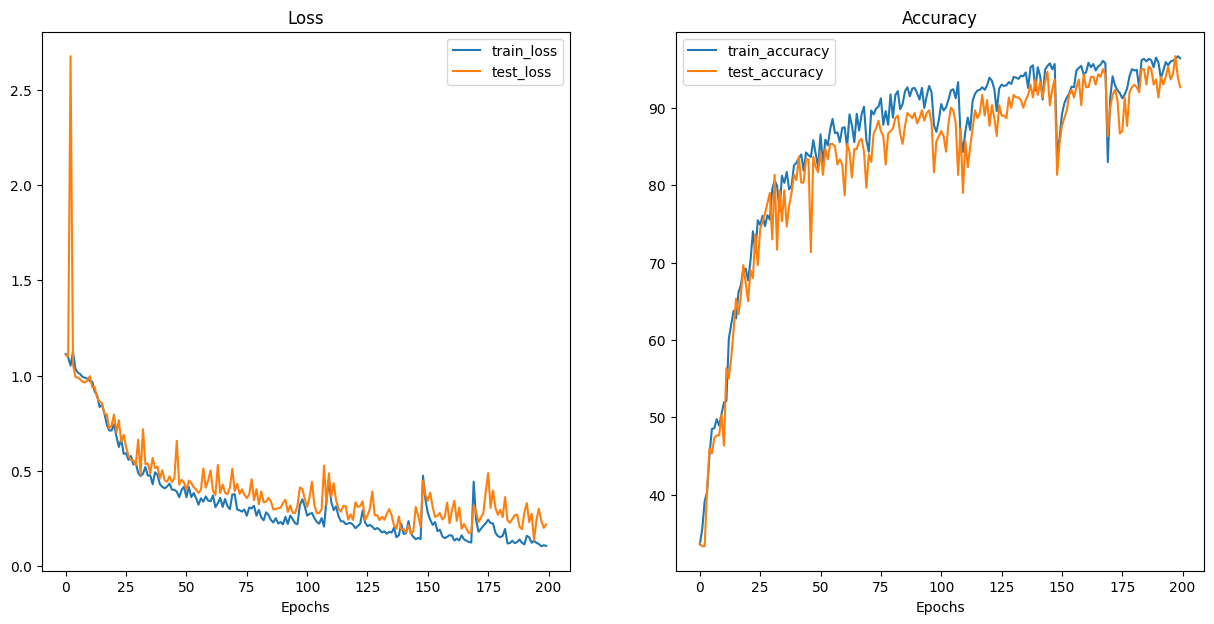

In [ ]:
from timeit import default_timer as timer
start_time = timer()
batch_train(
    model=model_0,
    train_data_loader=train_dataloader,
    test_data_loader=test_dataloader,
    loss_fn=loss_fn0,
    optimiser=optimiser0,
    epochs=NUM_EPOCHS,
    device=device,
    divisor = 1,
    loss_curves = True
)
end_time = timer()
from ml_functions import print_train_time
print_train_time(start=start_time,end=end_time,device=device)

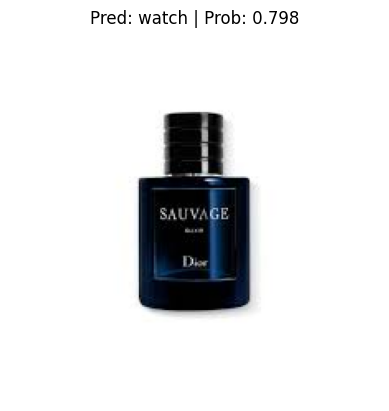

In [ ]:
from ml_functions import pred_and_plot_image
path = r"/content/drive/MyDrive/download.jpg"
pred_and_plot_image(
    model=model_0,
    image_path=path,
    class_names=train_dataset.classes,
    transform=transforms.Compose([
        transforms.Resize((224,224)),
        transforms.RandomHorizontalFlip(p=0.5)
    ]),
    device=device
)

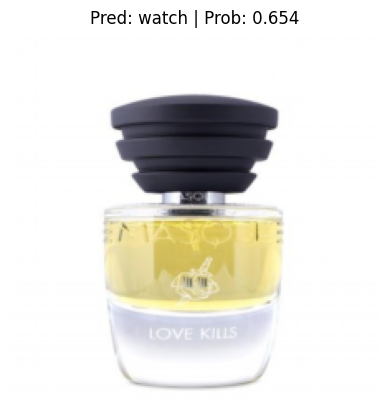

In [ ]:
path1 = r"/content/drive/MyDrive/download1.jpg"
pred_and_plot_image(
    model=model_0,
    image_path=path1,
    class_names=train_dataset.classes,
    transform=transforms.Compose([
        transforms.Resize((224,224)),
        transforms.RandomHorizontalFlip(p=0.5)
    ]),
    device=device
)

Epoch: 1 
 ---------------------------------------------------------

Train loss: 1.10229 | Train acc: 33.56% | Test loss: 1.09678 | Test acc: 35.00%

Epoch: 2 
 ---------------------------------------------------------
Epoch: 3 
 ---------------------------------------------------------

Train loss: 1.09532 | Train acc: 36.06% | Test loss: 1.08985 | Test acc: 34.00%

Epoch: 4 
 ---------------------------------------------------------
Epoch: 5 
 ---------------------------------------------------------

Train loss: 1.05974 | Train acc: 43.49% | Test loss: 1.01702 | Test acc: 46.33%

Epoch: 6 
 ---------------------------------------------------------
Epoch: 7 
 ---------------------------------------------------------

Train loss: 1.04034 | Train acc: 44.49% | Test loss: 0.99096 | Test acc: 47.67%

Epoch: 8 
 ---------------------------------------------------------
Epoch: 9 
 ---------------------------------------------------------

Train loss: 1.01289 | Train acc: 51.09% | Test los

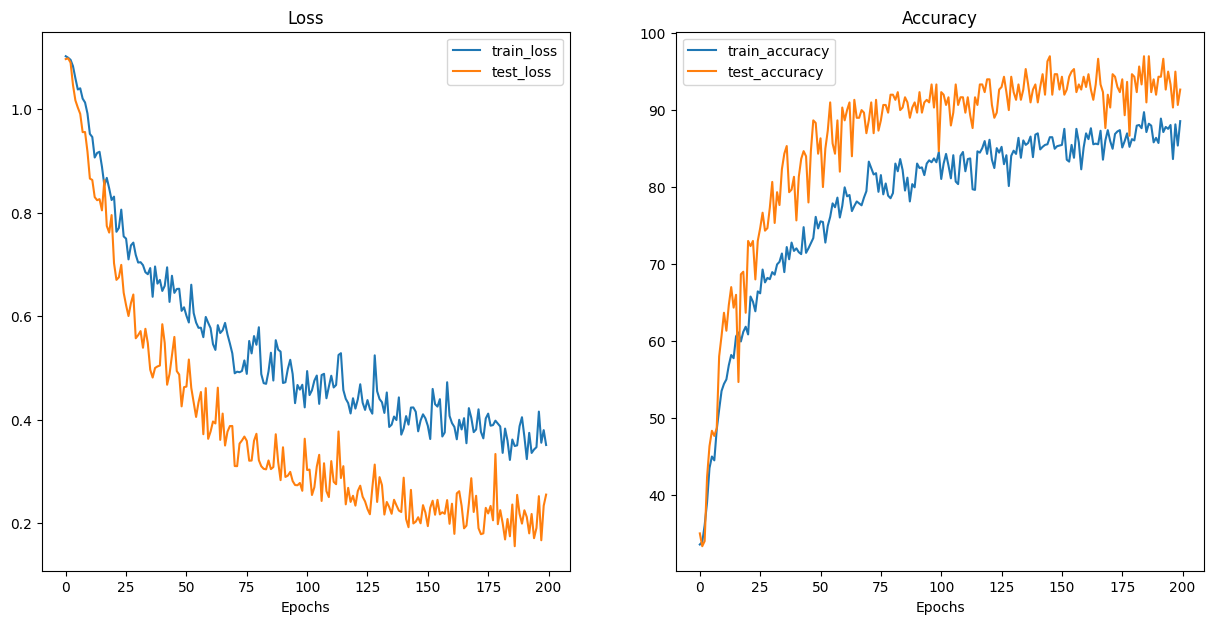

In [ ]:
from timeit import default_timer as timer
model_1 = TinyVGG(input=3, hidden=16, output=len(train_dataset.classes)).to(device)
optimiser1 = torch.optim.Adam(params=model_1.parameters(), lr=0.001)
start_time1 = timer()
batch_train(
    model=model_1,
    train_data_loader=aug_train_dataloader,
    test_data_loader=test_dataloader,
    loss_fn=loss_fn0,
    optimiser=optimiser1,
    epochs=NUM_EPOCHS,
    device=device,
    divisor = 2,
    loss_curves = True
)
end_time1 = timer()
from ml_functions import print_train_time
print_train_time(start=start_time1,end=end_time1,device=device)